# Greedy Best-First Search and A* for Maze Solving

## Step 1: Introduction to Informed Search

In the previous tutorial, we learned about **uninformed search** algorithms (DFS and BFS) that explore the search space without any knowledge about the goal location.

**Informed search** algorithms use **problem-specific knowledge** (called a **heuristic**) to guide the search towards the goal more efficiently.

### Key Concepts:

| Term | Symbol | Description |
|------|--------|-------------|
| **Heuristic** | h(n) | Estimated cost from node n to goal |
| **Path Cost** | g(n) | Actual cost from start to node n |
| **Evaluation Function** | f(n) | Used to decide which node to expand next |

### Two Algorithms We'll Learn:

1. **Greedy Best-First Search**: f(n) = h(n)
   - Only considers estimated distance to goal
   - Fast but **NOT optimal** (may not find shortest path)

2. **A\* Search**: f(n) = g(n) + h(n)
   - Considers both path cost AND heuristic
   - **Optimal** (finds shortest path if heuristic is admissible)

### What is a Heuristic?

A heuristic is an **estimate** of how far we are from the goal.

**Important:** Heuristics are **problem-specific** - they change based on the problem!

| Problem | Common Heuristics |
|---------|------------------|
| **Maze/Grid Navigation** | Manhattan Distance, Euclidean Distance |
| **8-Puzzle** | Number of misplaced tiles, Manhattan Distance of tiles |
| **Traveling Salesman** | Minimum Spanning Tree cost |
| **Route Finding (Maps)** | Straight-line (Euclidean) distance |
| **Game Playing (Chess)** | Piece values, board position evaluation |

### Heuristic for Maze: Manhattan Distance

For our maze problem (4-directional movement: up, down, left, right), we use **Manhattan Distance**:

```
h(n) = |row_current - row_goal| + |col_current - col_goal|
```

This counts the minimum number of horizontal and vertical moves needed (ignoring walls).

**Why Manhattan Distance for Maze?**
- We can only move in 4 directions (no diagonals)
- It never **overestimates** the actual cost (admissible)
- It's easy and fast to compute

### Our Maze (maze4.txt)

We'll work with this 7×12 maze:

```
 # # ###  #B   ← Row 0: Goal B at (0, 11)
 # #     ##    ← Row 1
   # # # ##    ← Row 2
# ## # # ##    ← Row 3
#    # #       ← Row 4
### ## #####   ← Row 5
A   ##         ← Row 6: Start A at (6, 0)
```

- `#` = Wall (cannot pass)
- ` ` (space) = Open path
- `A` = Start position (6, 0)
- `B` = Goal position (0, 11)

**Manhattan Distance from A to B:**
```
h(A) = |6 - 0| + |0 - 11| = 6 + 11 = 17
```

In [39]:
# Step 1: Load and display the maze
with open("maze4.txt") as f:
    maze_content = f.read()

print("Maze content:")
print(maze_content)

Maze content:
 # # ###  #B
 # #     ## 
   # # # ## 
# ## # # ## 
#    # #    
### ## #####
A   ##      



In [40]:
# Step 1b: Understanding Manhattan Distance
# Manhattan Distance = |row1 - row2| + |col1 - col2|

start = (6, 0)   # A's position
goal = (0, 11)   # B's position

def manhattan_distance(state, goal):
    """Calculate Manhattan distance from state to goal."""
    row1, col1 = state
    row2, col2 = goal
    return abs(row1 - row2) + abs(col1 - col2)

h_start = manhattan_distance(start, goal)
print(f"Start position: {start}")
print(f"Goal position: {goal}")
print(f"Manhattan distance h(A) = |{start[0]} - {goal[0]}| + |{start[1]} - {goal[1]}|")
print(f"                       = |{start[0] - goal[0]}| + |{start[1] - goal[1]}|")
print(f"                       = {abs(start[0] - goal[0])} + {abs(start[1] - goal[1])}")
print(f"                       = {h_start}")

Start position: (6, 0)
Goal position: (0, 11)
Manhattan distance h(A) = |6 - 0| + |0 - 11|
                       = |6| + |-11|
                       = 6 + 11
                       = 17


## Step 2: Parsing the Maze

Now we need to extract useful information from the maze text:
1. **Height** - number of rows
2. **Width** - number of columns  
3. **Start position** - where is 'A'?
4. **Goal position** - where is 'B'?
5. **Walls grid** - which cells are walls?

This is the same as the DFS/BFS tutorial, but we'll also compute the **heuristic value h(n)** for each cell.

In [41]:
# Step 2a: Split into lines and get dimensions
lines = maze_content.splitlines()

print("Lines in the maze:")
for i, line in enumerate(lines):
    print(f"  Row {i}: '{line}'")

Lines in the maze:
  Row 0: ' # # ###  #B'
  Row 1: ' # #     ## '
  Row 2: '   # # # ## '
  Row 3: '# ## # # ## '
  Row 4: '#    # #    '
  Row 5: '### ## #####'
  Row 6: 'A   ##      '


In [42]:
# Step 2b: Calculate height and width
height = len(lines)
width = max(len(line) for line in lines)

print(f"Height (number of rows): {height}")
print(f"Width (number of columns): {width}")

Height (number of rows): 7
Width (number of columns): 12


In [43]:
# Step 2c: Find start (A) and goal (B) positions
start = None
goal = None

for i in range(height):
    for j in range(len(lines[i])):
        if lines[i][j] == "A":
            start = (i, j)
        elif lines[i][j] == "B":
            goal = (i, j)

print(f"Start position (A): {start}")
print(f"Goal position (B): {goal}")

Start position (A): (6, 0)
Goal position (B): (0, 11)


In [44]:
# Step 2d: Create walls grid
# True = wall (cannot pass), False = open path (can walk)

walls = []
for i in range(height):
    row = []
    for j in range(width):
        # Handle case where line might be shorter than width
        if j >= len(lines[i]):
            row.append(False)  # Treat as open
        elif lines[i][j] == "#":
            row.append(True)   # Wall
        else:
            row.append(False)  # Open path (includes A, B, and spaces)
    walls.append(row)

print("Walls grid (True=wall, False=open):")
for i, row in enumerate(walls):
    print(f"  Row {i}: {row}")

Walls grid (True=wall, False=open):
  Row 0: [False, True, False, True, False, True, True, True, False, False, True, False]
  Row 1: [False, True, False, True, False, False, False, False, False, True, True, False]
  Row 2: [False, False, False, True, False, True, False, True, False, True, True, False]
  Row 3: [True, False, True, True, False, True, False, True, False, True, True, False]
  Row 4: [True, False, False, False, False, True, False, True, False, False, False, False]
  Row 5: [True, True, True, False, True, True, False, True, True, True, True, True]
  Row 6: [False, False, False, False, True, True, False, False, False, False, False, False]


In [45]:
# Step 2e: Visualize the parsed maze
print("Parsed Maze Visualization:")
print(f"Dimensions: {height} x {width}")
print(f"Start: {start}, Goal: {goal}")
print()

for i in range(height):
    for j in range(width):
        if (i, j) == start:
            print("A", end="")
        elif (i, j) == goal:
            print("B", end="")
        elif walls[i][j]:
            print("#", end="")
        else:
            print(" ", end="")
    print()  # New line after each row

Parsed Maze Visualization:
Dimensions: 7 x 12
Start: (6, 0), Goal: (0, 11)

 # # ###  #B
 # #     ## 
   # # # ## 
# ## # # ## 
#    # #    
### ## #####
A   ##      


### Step 2f: Heuristic Values for Each Cell

Now let's compute the **Manhattan distance h(n)** for each open cell in the maze. This shows how "close" each cell appears to be to the goal (ignoring walls).

In [46]:
# Step 2f: Compute and display heuristic h(n) for each cell
print("Heuristic values h(n) = Manhattan distance to goal B:")
print(f"Goal B is at: {goal}")
print()

for i in range(height):
    for j in range(width):
        if walls[i][j]:
            print("  #", end=" ")  # Wall
        else:
            h = manhattan_distance((i, j), goal)
            if (i, j) == start:
                print(f" A{h}", end=" ") if h < 10 else print(f"A{h}", end=" ")
            elif (i, j) == goal:
                print("  B", end=" ")
            else:
                print(f" {h:2d}", end=" ")
    print()

print()
print("Note: Numbers show h(n) - estimated distance to goal")
print("      Lower numbers = closer to goal (greedy prefers these)")
print("      A has h =", manhattan_distance(start, goal))
print("      B has h = 0 (it IS the goal)")

Heuristic values h(n) = Manhattan distance to goal B:
Goal B is at: (0, 11)

 11   #   9   #   7   #   #   #   3   2   #   B 
 12   #  10   #   8   7   6   5   4   #   #   1 
 13  12  11   #   9   #   7   #   5   #   #   2 
  #  13   #   #  10   #   8   #   6   #   #   3 
  #  14  13  12  11   #   9   #   7   6   5   4 
  #   #   #  13   #   #  10   #   #   #   #   # 
A17  16  15  14   #   #  11  10   9   8   7   6 

Note: Numbers show h(n) - estimated distance to goal
      Lower numbers = closer to goal (greedy prefers these)
      A has h = 17
      B has h = 0 (it IS the goal)


### Step 2 Summary

We now have all the parsed data we need:
- `height`, `width` - dimensions of the maze (7 × 12)
- `start` - tuple `(6, 0)` for starting position A
- `goal` - tuple `(0, 11)` for goal position B  
- `walls` - 2D list where `walls[row][col]` is `True` if wall, `False` if open
- `manhattan_distance(state, goal)` - heuristic function h(n)

**Key Insight for Informed Search:**
The heuristic values show that cells closer to B (top-right) have **lower h(n)** values. 
- Greedy Best-First will prefer expanding nodes with lower h(n)
- A* will balance h(n) with the actual path cost g(n)

**Next:** We need to understand states, actions, and how to find neighbors.

## Step 3: States, Actions, and Neighbors

**Key Concepts:**
- **State** = A position in the maze, represented as `(row, col)`
- **Action** = A movement direction: `"up"`, `"down"`, `"left"`, `"right"`
- **Neighbors** = Valid states we can reach from current state (not walls, not outside maze)
- **Step Cost** = Cost to move from one cell to another (= 1 for all moves in our maze)

### Movement in a Grid

```
                 col 0   col 1   col 2   col 3
                   ↓       ↓       ↓       ↓
  row 0  →       (0,0)   (0,1)   (0,2)   (0,3)
  row 1  →       (1,0)   (1,1)   (1,2)   (1,3)    ← UP: row - 1
  row 2  →       (2,0)   (2,1)  [CURRENT](2,3)   ← Current position
  row 3  →       (3,0)   (3,1)   (3,2)   (3,3)    ← DOWN: row + 1
                           ↑               ↑
                         LEFT           RIGHT
                        col - 1         col + 1
```

In [47]:
# Step 3a: Understanding movement directions
current_pos = (2, 3)  # Example position
row, col = current_pos

print(f"Current position: {current_pos}")
print()
print("Possible moves:")
print(f"  UP    → (row-1, col) = ({row}-1, {col}) = ({row-1}, {col})")
print(f"  DOWN  → (row+1, col) = ({row}+1, {col}) = ({row+1}, {col})")
print(f"  LEFT  → (row, col-1) = ({row}, {col}-1) = ({row}, {col-1})")
print(f"  RIGHT → (row, col+1) = ({row}, {col}+1) = ({row}, {col+1})")

Current position: (2, 3)

Possible moves:
  UP    → (row-1, col) = (2-1, 3) = (1, 3)
  DOWN  → (row+1, col) = (2+1, 3) = (3, 3)
  LEFT  → (row, col-1) = (2, 3-1) = (2, 2)
  RIGHT → (row, col+1) = (2, 3+1) = (2, 4)


In [48]:
# Step 3b: Checking if a move is valid
# A move is valid if:
#   1. The new position is inside the maze (not negative, not beyond height/width)
#   2. The new position is not a wall

def is_valid_move(r, c, height, width, walls):
    """Check if position (r, c) is a valid move."""
    # Check bounds
    if r < 0 or r >= height:
        return False
    if c < 0 or c >= width:
        return False
    # Check if wall
    if walls[r][c]:
        return False
    return True

# Test with some positions
test_positions = [(0, 11), (0, 0), (-1, 0), (6, 0), (6, 4)]
print("Testing is_valid_move:")
for pos in test_positions:
    r, c = pos
    valid = is_valid_move(r, c, height, width, walls)
    reason = ""
    if r < 0 or r >= height or c < 0 or c >= width:
        reason = "(out of bounds)"
    elif walls[r][c]:
        reason = "(wall)"
    else:
        reason = "(open path)"
    print(f"  Position {pos}: {valid} {reason}")

Testing is_valid_move:
  Position (0, 11): True (open path)
  Position (0, 0): True (open path)
  Position (-1, 0): False (out of bounds)
  Position (6, 0): True (open path)
  Position (6, 4): False (wall)


### The Neighbors Function

The `neighbors()` function returns all valid moves from a given state.

**For Informed Search**, we also need:
- **Step cost** = cost to make that move (= 1 for all moves)
- Later we'll compute **h(n)** for each neighbor to guide the search

**Function Output:** List of `(action, new_state, step_cost)` tuples

In [49]:
# Step 3c: The neighbors function
# Returns all valid (action, state, step_cost) tuples from a given state

def neighbors(state, height, width, walls):
    """Get all valid neighbors from a state."""
    row, col = state
    
    # All possible moves: (action_name, new_position)
    candidates = [
        ("up", (row - 1, col)),
        ("down", (row + 1, col)),
        ("left", (row, col - 1)),
        ("right", (row, col + 1))
    ]
    
    # Filter to keep only valid moves, include step_cost = 1
    result = []
    for action, (r, c) in candidates:
        if is_valid_move(r, c, height, width, walls):
            result.append((action, (r, c), 1))  # step_cost = 1
    
    return result

# Test: What are the neighbors of the start position?
print(f"Start position: {start}")
neighbors_of_start = neighbors(start, height, width, walls)
print(f"Neighbors of start:")
for action, new_state, cost in neighbors_of_start:
    h = manhattan_distance(new_state, goal)
    print(f"  Action '{action}' → {new_state}, step_cost={cost}, h(n)={h}")

Start position: (6, 0)
Neighbors of start:
  Action 'right' → (6, 1), step_cost=1, h(n)=16


In [50]:
# Step 3d: Manual exploration - tracing a few steps
# Let's see how we explore from start towards goal

print("Manual exploration from start:")
print()

current = start
g_cost = 0  # Path cost from start
print(f"Step 0: At {current}, g={g_cost}, h={manhattan_distance(current, goal)}, f={g_cost + manhattan_distance(current, goal)}")

# Get neighbors and show their f-values
print(f"\nNeighbors of {current}:")
for action, new_state, step_cost in neighbors(current, height, width, walls):
    new_g = g_cost + step_cost
    h = manhattan_distance(new_state, goal)
    f = new_g + h
    print(f"  '{action}' → {new_state}: g={new_g}, h={h}, f(n)=g+h={f}")

# Move to (6, 1)
current = (6, 1)
g_cost = 1
print(f"\nStep 1: Move RIGHT to {current}")
print(f"        g={g_cost}, h={manhattan_distance(current, goal)}, f={g_cost + manhattan_distance(current, goal)}")

print(f"\nNeighbors of {current}:")
for action, new_state, step_cost in neighbors(current, height, width, walls):
    new_g = g_cost + step_cost
    h = manhattan_distance(new_state, goal)
    f = new_g + h
    print(f"  '{action}' → {new_state}: g={new_g}, h={h}, f(n)=g+h={f}")

Manual exploration from start:

Step 0: At (6, 0), g=0, h=17, f=17

Neighbors of (6, 0):
  'right' → (6, 1): g=1, h=16, f(n)=g+h=17

Step 1: Move RIGHT to (6, 1)
        g=1, h=16, f=17

Neighbors of (6, 1):
  'left' → (6, 0): g=2, h=17, f(n)=g+h=19
  'right' → (6, 2): g=2, h=15, f(n)=g+h=17


### How Greedy vs A* Choose Neighbors

| Algorithm | Evaluation | Chooses based on |
|-----------|------------|------------------|
| **Greedy Best-First** | f(n) = h(n) | Lowest h(n) only |
| **A\*** | f(n) = g(n) + h(n) | Lowest g(n) + h(n) |

**Example:** If we have two neighbors:
- Neighbor A: g=5, h=3, f=8
- Neighbor B: g=2, h=7, f=9

**Greedy** picks Neighbor A (lower h=3)
**A\*** picks Neighbor A (lower f=8)

But if:
- Neighbor A: g=10, h=3, f=13
- Neighbor B: g=2, h=7, f=9

**Greedy** still picks A (lower h=3) - ignores that we traveled far!
**A\*** picks B (lower f=9) - balances path cost and estimate

### Step 3 Summary

We now understand:
- **State** = `(row, col)` position
- **Actions** = `"up"`, `"down"`, `"left"`, `"right"`
- **`neighbors(state)`** = returns list of `(action, new_state, step_cost)` for valid moves
- **Step cost** = 1 for all moves in our maze

**For Informed Search, each neighbor also has:**
- **g(n)** = path cost from start to reach this neighbor
- **h(n)** = heuristic estimate (Manhattan distance to goal)
- **f(n)** = evaluation function (h for Greedy, g+h for A*)

**Next:** The Node class - how to track g, h, f costs along with parent for path reconstruction.

## Step 4: The Node Class (Extended for Informed Search)

### Why do we need Nodes?

When we find the goal, we need to **trace back the path** to the start. A state `(row, col)` only tells us WHERE we are, not HOW we got there.

### Node for Uninformed Search (DFS/BFS):
```python
Node: state, parent, action
```

### Node for Informed Search (Greedy/A*):
```python
Node: state, parent, action, g_cost, h_cost, f_cost
```

**Additional attributes for informed search:**
| Attribute | Description |
|-----------|-------------|
| `g_cost` | Actual cost from start to this node |
| `h_cost` | Heuristic estimate from this node to goal |
| `f_cost` | Evaluation: g + h (A*) or just h (Greedy) |

In [51]:
# Step 4a: Define the Node class for Informed Search

class Node:
    def __init__(self, state, parent, action, g_cost=0, h_cost=0):
        self.state = state      # Current position (row, col)
        self.parent = parent    # The node we came from (None for start)
        self.action = action    # Action taken to reach this node (None for start)
        self.g_cost = g_cost    # Actual cost from start to this node
        self.h_cost = h_cost    # Heuristic estimate to goal
        self.f_cost = g_cost + h_cost  # Total evaluation (for A*)
    
    def __lt__(self, other):
        """For priority queue comparison - lower f_cost has higher priority."""
        return self.f_cost < other.f_cost

# Create the starting node
h_start = manhattan_distance(start, goal)
start_node = Node(state=start, parent=None, action=None, g_cost=0, h_cost=h_start)

print("Start node created:")
print(f"  state:  {start_node.state}")
print(f"  parent: {start_node.parent}")
print(f"  action: {start_node.action}")
print(f"  g_cost: {start_node.g_cost} (path cost from start)")
print(f"  h_cost: {start_node.h_cost} (heuristic to goal)")
print(f"  f_cost: {start_node.f_cost} (g + h)")

Start node created:
  state:  (6, 0)
  parent: None
  action: None
  g_cost: 0 (path cost from start)
  h_cost: 17 (heuristic to goal)
  f_cost: 17 (g + h)


### Step 4b: Creating Child Nodes

When we explore a node's neighbors, we create **child nodes** with updated costs:

```
         Parent Node                    Child Node
        state = (6, 0)                 state = (6, 1)
        g_cost = 0                     g_cost = 0 + 1 = 1
        h_cost = 17                    h_cost = manhattan((6,1), goal) = 16
        f_cost = 17                    f_cost = 1 + 16 = 17
             |                              ↑
             | action = "right"             |
             | step_cost = 1                |
             +------------------------------+
```

**Key formula for child node:**
- `child.g_cost = parent.g_cost + step_cost`
- `child.h_cost = manhattan_distance(child.state, goal)`
- `child.f_cost = child.g_cost + child.h_cost`

In [52]:
# Step 4b: Creating child nodes from neighbors

# Get neighbors of start node's state
neighbor_list = neighbors(start_node.state, height, width, walls)

print(f"Parent node: state={start_node.state}, g={start_node.g_cost}, h={start_node.h_cost}, f={start_node.f_cost}")
print(f"\nCreating child nodes for each neighbor:")
print()

child_nodes = []
for action, new_state, step_cost in neighbor_list:
    # Calculate costs for child
    child_g = start_node.g_cost + step_cost
    child_h = manhattan_distance(new_state, goal)
    
    # Create child node
    child_node = Node(
        state=new_state,
        parent=start_node,
        action=action,
        g_cost=child_g,
        h_cost=child_h
    )
    child_nodes.append(child_node)
    
    print(f"  Action '{action}' → Child node:")
    print(f"    state:  {child_node.state}")
    print(f"    g_cost: {start_node.g_cost} + {step_cost} = {child_node.g_cost}")
    print(f"    h_cost: {child_node.h_cost}")
    print(f"    f_cost: {child_node.g_cost} + {child_node.h_cost} = {child_node.f_cost}")
    print()

Parent node: state=(6, 0), g=0, h=17, f=17

Creating child nodes for each neighbor:

  Action 'right' → Child node:
    state:  (6, 1)
    g_cost: 0 + 1 = 1
    h_cost: 16
    f_cost: 1 + 16 = 17



### Step 4c: Path Reconstruction

When we reach the goal, we trace back through parent pointers to reconstruct the path.

```
Goal Node → parent → parent → parent → ... → Start Node (parent=None)
```

This is the same as DFS/BFS - the costs (g, h, f) are used for **choosing which node to expand**, not for path reconstruction.

In [53]:
# Step 4c: Path reconstruction example
# Let's manually create a small chain of nodes to demonstrate

# Simulating a path: start(6,0) → right(6,1) → right(6,2) → right(6,3)
node1 = Node(state=(6, 0), parent=None, action=None, 
             g_cost=0, h_cost=manhattan_distance((6,0), goal))

node2 = Node(state=(6, 1), parent=node1, action="right",
             g_cost=1, h_cost=manhattan_distance((6,1), goal))

node3 = Node(state=(6, 2), parent=node2, action="right",
             g_cost=2, h_cost=manhattan_distance((6,2), goal))

node4 = Node(state=(6, 3), parent=node3, action="right",
             g_cost=3, h_cost=manhattan_distance((6,3), goal))

print("Chain of nodes created:")
print(f"  node1: {node1.state}, g={node1.g_cost}, h={node1.h_cost}, f={node1.f_cost} (start)")
print(f"  node2: {node2.state}, g={node2.g_cost}, h={node2.h_cost}, f={node2.f_cost} ← via '{node2.action}'")
print(f"  node3: {node3.state}, g={node3.g_cost}, h={node3.h_cost}, f={node3.f_cost} ← via '{node3.action}'")
print(f"  node4: {node4.state}, g={node4.g_cost}, h={node4.h_cost}, f={node4.f_cost} ← via '{node4.action}'")

Chain of nodes created:
  node1: (6, 0), g=0, h=17, f=17 (start)
  node2: (6, 1), g=1, h=16, f=17 ← via 'right'
  node3: (6, 2), g=2, h=15, f=17 ← via 'right'
  node4: (6, 3), g=3, h=14, f=17 ← via 'right'


In [54]:
# Step 4d: Reconstructing the path by following parent pointers

# Suppose node4 is our "goal" - trace back to find the path
current_node = node4

actions = []  # Actions taken
cells = []    # Cells visited

# Keep following parent until we reach the start (parent=None)
while current_node.parent is not None:
    actions.append(current_node.action)
    cells.append(current_node.state)
    current_node = current_node.parent  # Move to parent

# Reverse because we traced backwards (goal → start)
actions.reverse()
cells.reverse()

print("Path reconstruction (tracing from node4 back to start):")
print(f"  Actions: {actions}")
print(f"  Cells:   {cells}")
print()
print("The path from start to node4:")
print(f"  Start at {node1.state} (g=0, f={node1.f_cost})")
for i, (action, cell) in enumerate(zip(actions, cells)):
    print(f"  Step {i+1}: '{action}' → {cell}")

Path reconstruction (tracing from node4 back to start):
  Actions: ['right', 'right', 'right']
  Cells:   [(6, 1), (6, 2), (6, 3)]

The path from start to node4:
  Start at (6, 0) (g=0, f=17)
  Step 1: 'right' → (6, 1)
  Step 2: 'right' → (6, 2)
  Step 3: 'right' → (6, 3)


### Step 4 Summary

The **Node** class for informed search stores:

| Attribute | Description | Used for |
|-----------|-------------|----------|
| `state` | Position `(row, col)` | Identifying where we are |
| `parent` | Node we came from | Path reconstruction |
| `action` | How we got here | Path reconstruction |
| `g_cost` | Cost from start to here | A* evaluation |
| `h_cost` | Heuristic estimate to goal | Greedy & A* evaluation |
| `f_cost` | g + h (total evaluation) | Priority in frontier |

**Key formulas when creating child node:**
```python
child.g_cost = parent.g_cost + step_cost
child.h_cost = manhattan_distance(child.state, goal)
child.f_cost = child.g_cost + child.h_cost
```

**The `__lt__` method** allows nodes to be compared by f_cost for priority queue ordering.

**Next:** The Priority Queue Frontier - how we select which node to expand next (this is the KEY difference from DFS/BFS!).

## Step 5: The Priority Queue Frontier

### The KEY Difference from DFS/BFS

In **uninformed search**, we used:
- **Stack (LIFO)** for DFS → Always expand the most recently added node
- **Queue (FIFO)** for BFS → Always expand the oldest added node

In **informed search**, we use:
- **Priority Queue** → Always expand the node with **lowest f(n)**

| Algorithm | Data Structure | Removes | Order |
|-----------|----------------|---------|-------|
| DFS | Stack | Last added | LIFO |
| BFS | Queue | First added | FIFO |
| **Greedy** | Priority Queue | **Lowest h(n)** | Best-first |
| **A*** | Priority Queue | **Lowest g(n)+h(n)** | Best-first |

### How Priority Queue Works

A **Priority Queue** (also called a **Min-Heap**) always gives us the element with the **smallest priority value**.

```
Add nodes with different f-costs:     Remove order (lowest f first):

    ┌─────────────────────┐           
    │ Node A: f = 15      │           1. Node C: f = 8  (smallest)
    │ Node B: f = 12      │    →      2. Node B: f = 12
    │ Node C: f = 8       │           3. Node A: f = 15 (largest)
    │ Node D: f = 10      │           4. Node D: f = 10
    └─────────────────────┘           
                                      Wait... D should come before A!
    Internally sorted by f:           
    [C(8), D(10), B(12), A(15)]       Correct order: C(8), D(10), B(12), A(15)
```

**Python's `heapq` module** provides an efficient priority queue implementation.

In [55]:
# Step 5a: Understanding heapq (Python's priority queue)
import heapq

# Simple demonstration with numbers
pq = []

# Add elements (heappush)
print("Adding elements to priority queue:")
for value in [15, 12, 8, 10]:
    heapq.heappush(pq, value)
    print(f"  Push {value} → heap: {pq}")

print()

# Remove elements (heappop) - always returns smallest
print("Removing elements (always smallest first):")
while pq:
    value = heapq.heappop(pq)
    print(f"  Pop {value} → heap: {pq}")

Adding elements to priority queue:
  Push 15 → heap: [15]
  Push 12 → heap: [12, 15]
  Push 8 → heap: [8, 15, 12]
  Push 10 → heap: [8, 10, 12, 15]

Removing elements (always smallest first):
  Pop 8 → heap: [10, 15, 12]
  Pop 10 → heap: [12, 15]
  Pop 12 → heap: [15]
  Pop 15 → heap: []


In [56]:
# Step 5b: Using heapq with our Node class
# heapq compares elements using < operator, which calls our __lt__ method

# Create some test nodes with different f-costs
test_nodes = [
    Node(state=(6, 0), parent=None, action=None, g_cost=0, h_cost=17),   # f=17
    Node(state=(6, 1), parent=None, action=None, g_cost=1, h_cost=16),   # f=17
    Node(state=(5, 3), parent=None, action=None, g_cost=4, h_cost=13),   # f=17
    Node(state=(4, 4), parent=None, action=None, g_cost=5, h_cost=11),   # f=16
]

print("Nodes to add:")
for n in test_nodes:
    print(f"  state={n.state}, g={n.g_cost}, h={n.h_cost}, f={n.f_cost}")

# Add to priority queue
pq = []
counter = 0  # Tie-breaker for equal f-costs
for node in test_nodes:
    # heapq uses tuples: (f_cost, counter, node)
    # counter breaks ties when f_costs are equal
    heapq.heappush(pq, (node.f_cost, counter, node))
    counter += 1

print("\nRemoving nodes (lowest f-cost first):")
while pq:
    f, _, node = heapq.heappop(pq)
    print(f"  f={f}: state={node.state}, g={node.g_cost}, h={node.h_cost}")

Nodes to add:
  state=(6, 0), g=0, h=17, f=17
  state=(6, 1), g=1, h=16, f=17
  state=(5, 3), g=4, h=13, f=17
  state=(4, 4), g=5, h=11, f=16

Removing nodes (lowest f-cost first):
  f=16: state=(4, 4), g=5, h=11
  f=17: state=(6, 0), g=0, h=17
  f=17: state=(6, 1), g=1, h=16
  f=17: state=(5, 3), g=4, h=13


### The PriorityQueueFrontier Class

Now let's create a frontier class that:
1. Stores nodes in a priority queue (min-heap by f-cost)
2. Can check if a state is already in the frontier
3. Always removes the node with **lowest f-cost**

In [57]:
# Step 5c: PriorityQueueFrontier class

class PriorityQueueFrontier:
    """
    Priority queue frontier for informed search algorithms.
    Always returns the node with lowest f_cost.
    """
    def __init__(self):
        self.frontier = []      # List of (f_cost, counter, node) tuples
        self.counter = 0        # Tie-breaker for equal f_costs
        self.states_in_frontier = set()  # For quick state lookup
    
    def add(self, node):
        """Add a node to the frontier."""
        heapq.heappush(self.frontier, (node.f_cost, self.counter, node))
        self.counter += 1
        self.states_in_frontier.add(node.state)
    
    def contains_state(self, state):
        """Check if a state is in the frontier."""
        return state in self.states_in_frontier
    
    def empty(self):
        """Check if frontier is empty."""
        return len(self.frontier) == 0
    
    def remove(self):
        """Remove and return the node with lowest f_cost."""
        if self.empty():
            raise Exception("empty frontier")
        
        # Pop until we get a valid node (skip outdated entries)
        while self.frontier:
            f_cost, counter, node = heapq.heappop(self.frontier)
            # Check if this state is still in frontier (not already removed)
            if node.state in self.states_in_frontier:
                self.states_in_frontier.remove(node.state)
                return node
        
        raise Exception("empty frontier")

print("PriorityQueueFrontier class defined!")

PriorityQueueFrontier class defined!


In [58]:
# Step 5d: Testing the PriorityQueueFrontier

frontier = PriorityQueueFrontier()

# Create nodes with different f-costs
nodes_to_add = [
    Node(state=(6, 0), parent=None, action=None, g_cost=0, h_cost=17),   # f=17
    Node(state=(6, 1), parent=None, action=None, g_cost=1, h_cost=16),   # f=17
    Node(state=(4, 4), parent=None, action=None, g_cost=5, h_cost=11),   # f=16 ← lowest!
    Node(state=(5, 3), parent=None, action=None, g_cost=4, h_cost=13),   # f=17
]

print("Adding nodes to PriorityQueueFrontier:")
for node in nodes_to_add:
    frontier.add(node)
    print(f"  Added state={node.state}, f={node.f_cost}")

print(f"\nFrontier empty? {frontier.empty()}")
print(f"Contains state (6, 0)? {frontier.contains_state((6, 0))}")
print(f"Contains state (0, 0)? {frontier.contains_state((0, 0))}")

print("\nRemoving nodes (lowest f-cost first):")
while not frontier.empty():
    node = frontier.remove()
    print(f"  Removed: state={node.state}, g={node.g_cost}, h={node.h_cost}, f={node.f_cost}")

print(f"\nFrontier empty now? {frontier.empty()}")

Adding nodes to PriorityQueueFrontier:
  Added state=(6, 0), f=17
  Added state=(6, 1), f=17
  Added state=(4, 4), f=16
  Added state=(5, 3), f=17

Frontier empty? False
Contains state (6, 0)? True
Contains state (0, 0)? False

Removing nodes (lowest f-cost first):
  Removed: state=(4, 4), g=5, h=11, f=16
  Removed: state=(6, 0), g=0, h=17, f=17
  Removed: state=(6, 1), g=1, h=16, f=17
  Removed: state=(5, 3), g=4, h=13, f=17

Frontier empty now? True


### Step 5 Summary

The **Priority Queue Frontier** is the KEY difference between informed and uninformed search:

| Component | DFS | BFS | Greedy / A* |
|-----------|-----|-----|-------------|
| Data Structure | Stack | Queue | **Priority Queue** |
| Ordering | LIFO | FIFO | **By f(n)** |
| Next node | Most recent | Oldest | **Lowest f-cost** |

**PriorityQueueFrontier methods:**

| Method | Description |
|--------|-------------|
| `add(node)` | Add node to frontier (sorted by f_cost) |
| `remove()` | Remove and return node with **lowest f_cost** |
| `empty()` | Check if frontier is empty |
| `contains_state(state)` | Check if state already in frontier |

**Why this matters:**
- Greedy: f(n) = h(n) → expands node that **looks** closest to goal
- A*: f(n) = g(n) + h(n) → expands node with best **total** estimated cost

**Python implementation:** Uses `heapq` (min-heap) which efficiently maintains sorted order.

**Next:** Putting it all together - the complete search algorithms!

## Step 6: The Search Algorithms

Now we'll implement both **Greedy Best-First Search** and **A\* Search**.

### Algorithm Structure (same for both)

```
1. Initialize frontier with start node
2. Initialize empty explored set
3. Loop:
   a. If frontier is empty → no solution
   b. Remove node with lowest f(n) from frontier
   c. If node is goal → return solution (trace back path)
   d. Add node's state to explored set
   e. For each neighbor:
      - If not in frontier and not explored → add to frontier
```

### The ONLY Difference: How f(n) is calculated

| Algorithm | f(n) | What it prioritizes |
|-----------|------|---------------------|
| **Greedy Best-First** | f(n) = h(n) | Nodes that LOOK closest to goal |
| **A\*** | f(n) = g(n) + h(n) | Nodes with best TOTAL estimated cost |

This single difference has major implications:
- **Greedy**: Fast but may not find optimal path (ignores how far we've traveled)
- **A\***: Finds optimal path (balances actual cost + estimated remaining cost)

In [59]:
# Step 6a: Greedy Best-First Search Implementation

def solve_greedy(start, goal, height, width, walls, heuristic=manhattan_distance):
    """
    Greedy Best-First Search.
    
    f(n) = h(n) only - expands node that appears closest to goal.
    
    Properties:
    - NOT optimal: May not find shortest path
    - Fast: Often finds a solution quickly
    - Greedy: Always picks the "seemingly" best option
    
    Returns:
        (actions, cells, num_explored) or raises Exception if no solution
    """
    num_explored = 0
    
    # Initialize start node
    h = heuristic(start, goal)
    start_node = Node(state=start, parent=None, action=None, g_cost=0, h_cost=h)
    # KEY: For Greedy, f(n) = h(n) only!
    start_node.f_cost = h  # Override f_cost to be just h
    
    # Initialize frontier with start node
    frontier = PriorityQueueFrontier()
    frontier.add(start_node)
    
    # Initialize explored set
    explored = set()
    
    # Search loop
    while True:
        # If frontier is empty, no solution
        if frontier.empty():
            raise Exception("No solution found")
        
        # Remove node with lowest f(n) = h(n)
        node = frontier.remove()
        num_explored += 1
        
        # Goal check
        if node.state == goal:
            # Trace back path
            actions = []
            cells = []
            while node.parent is not None:
                actions.append(node.action)
                cells.append(node.state)
                node = node.parent
            actions.reverse()
            cells.reverse()
            return (actions, cells, num_explored, explored)
        
        # Mark as explored
        explored.add(node.state)
        
        # Expand neighbors
        for action, state, step_cost in neighbors(node.state, height, width, walls):
            if not frontier.contains_state(state) and state not in explored:
                h = heuristic(state, goal)
                child = Node(
                    state=state,
                    parent=node,
                    action=action,
                    g_cost=node.g_cost + step_cost,
                    h_cost=h
                )
                # KEY: For Greedy, f(n) = h(n) only!
                child.f_cost = h
                frontier.add(child)

print("Greedy Best-First Search function defined!")

Greedy Best-First Search function defined!


In [60]:
# Step 6b: A* Search Implementation

def solve_astar(start, goal, height, width, walls, heuristic=manhattan_distance):
    """
    A* Search.
    
    f(n) = g(n) + h(n) - considers both path cost AND heuristic.
    
    Properties:
    - OPTIMAL: Finds shortest path (if heuristic is admissible)
    - COMPLETE: Will find a solution if one exists
    - Efficient: Explores fewer nodes than BFS in most cases
    
    Returns:
        (actions, cells, num_explored, explored) or raises Exception if no solution
    """
    num_explored = 0
    
    # Initialize start node
    h = heuristic(start, goal)
    start_node = Node(state=start, parent=None, action=None, g_cost=0, h_cost=h)
    # For A*: f(n) = g(n) + h(n) - already set in Node.__init__
    
    # Initialize frontier with start node
    frontier = PriorityQueueFrontier()
    frontier.add(start_node)
    
    # Initialize explored set
    explored = set()
    
    # Search loop
    while True:
        # If frontier is empty, no solution
        if frontier.empty():
            raise Exception("No solution found")
        
        # Remove node with lowest f(n) = g(n) + h(n)
        node = frontier.remove()
        num_explored += 1
        
        # Goal check
        if node.state == goal:
            # Trace back path
            actions = []
            cells = []
            while node.parent is not None:
                actions.append(node.action)
                cells.append(node.state)
                node = node.parent
            actions.reverse()
            cells.reverse()
            return (actions, cells, num_explored, explored)
        
        # Mark as explored
        explored.add(node.state)
        
        # Expand neighbors
        for action, state, step_cost in neighbors(node.state, height, width, walls):
            if not frontier.contains_state(state) and state not in explored:
                new_g_cost = node.g_cost + step_cost
                h = heuristic(state, goal)
                child = Node(
                    state=state,
                    parent=node,
                    action=action,
                    g_cost=new_g_cost,
                    h_cost=h
                )
                # For A*: f(n) = g(n) + h(n) - already set correctly!
                frontier.add(child)

print("A* Search function defined!")

A* Search function defined!


### Step 6c: The Key Difference in Code

Look at these two lines - this is the ONLY difference:

**Greedy Best-First:**
```python
child.f_cost = h  # f(n) = h(n) only
```

**A\*:**
```python
child.f_cost = new_g_cost + h  # f(n) = g(n) + h(n) - set in Node.__init__
```

Everything else is identical! The frontier always removes the node with lowest `f_cost`, but what `f_cost` means differs between the algorithms.

In [61]:
# Step 6d: Run Greedy Best-First Search on maze4

print("=" * 50)
print("GREEDY BEST-FIRST SEARCH on maze4")
print("=" * 50)

actions_greedy, cells_greedy, explored_count_greedy, explored_set_greedy = solve_greedy(
    start, goal, height, width, walls
)

print(f"\nSolution found!")
print(f"States explored: {explored_count_greedy}")
print(f"Path length: {len(actions_greedy)} steps")
print(f"\nActions: {actions_greedy}")
print(f"\nPath cells: {cells_greedy}")

GREEDY BEST-FIRST SEARCH on maze4

Solution found!
States explored: 28
Path length: 23 steps

Actions: ['right', 'right', 'right', 'up', 'up', 'right', 'up', 'up', 'up', 'right', 'right', 'right', 'right', 'down', 'down', 'down', 'right', 'right', 'right', 'up', 'up', 'up', 'up']

Path cells: [(6, 1), (6, 2), (6, 3), (5, 3), (4, 3), (4, 4), (3, 4), (2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (2, 8), (3, 8), (4, 8), (4, 9), (4, 10), (4, 11), (3, 11), (2, 11), (1, 11), (0, 11)]


In [62]:
# Step 6e: Run A* Search on maze4

print("=" * 50)
print("A* SEARCH on maze4")
print("=" * 50)

actions_astar, cells_astar, explored_count_astar, explored_set_astar = solve_astar(
    start, goal, height, width, walls
)

print(f"\nSolution found!")
print(f"States explored: {explored_count_astar}")
print(f"Path length: {len(actions_astar)} steps")
print(f"\nActions: {actions_astar}")
print(f"\nPath cells: {cells_astar}")

A* SEARCH on maze4

Solution found!
States explored: 40
Path length: 23 steps

Actions: ['right', 'right', 'right', 'up', 'up', 'right', 'up', 'up', 'up', 'right', 'right', 'right', 'right', 'down', 'down', 'down', 'right', 'right', 'right', 'up', 'up', 'up', 'up']

Path cells: [(6, 1), (6, 2), (6, 3), (5, 3), (4, 3), (4, 4), (3, 4), (2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (2, 8), (3, 8), (4, 8), (4, 9), (4, 10), (4, 11), (3, 11), (2, 11), (1, 11), (0, 11)]


In [63]:
# Step 6f: Compare Results

print("=" * 50)
print("COMPARISON: Greedy vs A*")
print("=" * 50)

print(f"\n{'Metric':<25} {'Greedy':>10} {'A*':>10}")
print("-" * 50)
print(f"{'States explored':<25} {explored_count_greedy:>10} {explored_count_astar:>10}")
print(f"{'Path length (steps)':<25} {len(actions_greedy):>10} {len(actions_astar):>10}")

print("\n" + "=" * 50)
if len(actions_greedy) == len(actions_astar):
    print("Both algorithms found the same length path!")
elif len(actions_greedy) > len(actions_astar):
    print(f"A* found a SHORTER path! ({len(actions_astar)} vs {len(actions_greedy)} steps)")
    print("This shows Greedy is NOT optimal - it can miss shorter paths.")
else:
    print(f"Greedy found a shorter path (unusual with admissible heuristic)")

COMPARISON: Greedy vs A*

Metric                        Greedy         A*
--------------------------------------------------
States explored                   28         40
Path length (steps)               23         23

Both algorithms found the same length path!


In [64]:
# Step 6g: Visualize solutions on the maze

def print_maze_with_solution(walls, start, goal, solution_cells, title):
    """Print maze with solution path marked."""
    print(f"\n{title}")
    print("-" * 20)
    solution_set = set(solution_cells)
    
    for i in range(len(walls)):
        for j in range(len(walls[0])):
            if (i, j) == start:
                print("A", end="")
            elif (i, j) == goal:
                print("B", end="")
            elif walls[i][j]:
                print("#", end="")
            elif (i, j) in solution_set:
                print("*", end="")
            else:
                print(" ", end="")
        print()

print_maze_with_solution(walls, start, goal, cells_greedy, 
                         f"Greedy Solution ({len(cells_greedy)} steps)")

print_maze_with_solution(walls, start, goal, cells_astar,
                         f"A* Solution ({len(cells_astar)} steps)")


Greedy Solution (23 steps)
--------------------
 # # ###  #B
 # #*****##*
   #*# #*##*
# ##*# #*##*
#  **# #****
###*## #####
A***##      

A* Solution (23 steps)
--------------------
 # # ###  #B
 # #*****##*
   #*# #*##*
# ##*# #*##*
#  **# #****
###*## #####
A***##      


In [65]:
# Step 6h: Visualize explored states

def print_maze_with_explored(walls, start, goal, solution_cells, explored_set, title):
    """Print maze showing explored states and solution path."""
    print(f"\n{title}")
    print("-" * 40)
    print("Legend: A=start, B=goal, *=solution path, .=explored, #=wall")
    print()
    solution_set = set(solution_cells)
    
    for i in range(len(walls)):
        for j in range(len(walls[0])):
            if (i, j) == start:
                print("A", end="")
            elif (i, j) == goal:
                print("B", end="")
            elif walls[i][j]:
                print("#", end="")
            elif (i, j) in solution_set:
                print("*", end="")
            elif (i, j) in explored_set:
                print(".", end="")
            else:
                print(" ", end="")
        print()

print_maze_with_explored(walls, start, goal, cells_greedy, explored_set_greedy,
                         f"Greedy: Explored {explored_count_greedy} states")

print_maze_with_explored(walls, start, goal, cells_astar, explored_set_astar,
                         f"A*: Explored {explored_count_astar} states")


Greedy: Explored 28 states
----------------------------------------
Legend: A=start, B=goal, *=solution path, .=explored, #=wall

 # #.###..#B
 # #*****##*
   #*#.#*##*
# ##*# #*##*
#  **# #****
###*## #####
A***##      

A*: Explored 40 states
----------------------------------------
Legend: A=start, B=goal, *=solution path, .=explored, #=wall

.#.#.###..#B
.#.#*****##*
...#*#.#*##*
#.##*#.#*##*
#..**#.#****
###*## #####
A***##      


### Step 6 Summary

We implemented both informed search algorithms:

| Algorithm | f(n) | Optimal? | Why? |
|-----------|------|----------|------|
| **Greedy Best-First** | h(n) | No | Ignores path cost - may find longer path |
| **A\*** | g(n) + h(n) | Yes* | Balances actual cost + estimate |

*A\* is optimal when the heuristic is **admissible** (never overestimates).

**Key observations:**
1. Both algorithms use the same structure (frontier, explored set, expand neighbors)
2. The ONLY difference is how f(n) is calculated
3. Greedy may explore fewer states but find a longer path
4. A* guarantees the shortest path with an admissible heuristic

**The explored states visualization shows:**
- How each algorithm "thinks" about the problem differently
- Greedy heads straight toward the goal (low h values)
- A* considers both distance traveled AND distance remaining

**Next:** We'll create a complete Maze class that packages everything together with image output!

## Step 7: The Complete Maze Class

Now let's package everything into a clean, reusable `Maze` class that:

1. **Loads** a maze from a file
2. **Parses** dimensions, start, goal, and walls
3. **Solves** using Greedy Best-First or A* Search
4. **Prints** the maze with solution to terminal
5. **Outputs** a colorful image showing the solution

This is the same pattern we used for DFS/BFS, but now with informed search algorithms!

In [66]:
# Step 7a: The Complete Maze Class

class Maze:
    """
    Complete Maze class with Greedy Best-First and A* Search.
    
    Usage:
        m = Maze("maze4.txt")
        m.solve_astar()  # or m.solve_greedy()
        m.print()
        m.output_image("solution.png")
    """
    
    def __init__(self, filename):
        """Load and parse a maze from a file."""
        
        # Read file
        with open(filename) as f:
            contents = f.read()
        
        # Validate start and goal
        if contents.count("A") != 1:
            raise Exception("Maze must have exactly one start point (A)")
        if contents.count("B") != 1:
            raise Exception("Maze must have exactly one goal (B)")
        
        # Determine height and width
        contents = contents.splitlines()
        self.height = len(contents)
        self.width = max(len(line) for line in contents)
        
        # Build walls grid and find start/goal
        self.walls = []
        for i in range(self.height):
            row = []
            for j in range(self.width):
                try:
                    if contents[i][j] == "A":
                        self.start = (i, j)
                        row.append(False)
                    elif contents[i][j] == "B":
                        self.goal = (i, j)
                        row.append(False)
                    elif contents[i][j] == " ":
                        row.append(False)
                    else:
                        row.append(True)  # Wall
                except IndexError:
                    row.append(False)  # Treat short lines as open
            self.walls.append(row)
        
        # Initialize solution tracking
        self.solution = None
        self.num_explored = 0
        self.explored = set()
    
    def print(self):
        """Print the maze, showing solution if available."""
        solution = self.solution[1] if self.solution is not None else None
        print()
        for i, row in enumerate(self.walls):
            for j, col in enumerate(row):
                if col:
                    print("█", end="")
                elif (i, j) == self.start:
                    print("A", end="")
                elif (i, j) == self.goal:
                    print("B", end="")
                elif solution is not None and (i, j) in solution:
                    print("*", end="")
                else:
                    print(" ", end="")
            print()
        print()
    
    def neighbors(self, state):
        """Get all valid neighbors from a state."""
        row, col = state
        candidates = [
            ("up", (row - 1, col)),
            ("down", (row + 1, col)),
            ("left", (row, col - 1)),
            ("right", (row, col + 1))
        ]
        
        result = []
        for action, (r, c) in candidates:
            if 0 <= r < self.height and 0 <= c < self.width and not self.walls[r][c]:
                result.append((action, (r, c), 1))  # step_cost = 1
        return result

print("Maze class (Part 1: __init__, print, neighbors) defined!")

Maze class (Part 1: __init__, print, neighbors) defined!


In [67]:
# Step 7b: Add solve methods to Maze class

# We'll add methods to the Maze class using Python's ability to add methods dynamically

def solve_greedy_method(self, heuristic=manhattan_distance):
    """
    Solve using Greedy Best-First Search.
    f(n) = h(n) only - expands node closest to goal.
    """
    self.num_explored = 0
    
    # Initialize with start node
    h = heuristic(self.start, self.goal)
    start_node = Node(state=self.start, parent=None, action=None, g_cost=0, h_cost=h)
    start_node.f_cost = h  # Greedy: f(n) = h(n)
    
    frontier = PriorityQueueFrontier()
    frontier.add(start_node)
    self.explored = set()
    
    while True:
        if frontier.empty():
            raise Exception("No solution")
        
        node = frontier.remove()
        self.num_explored += 1
        
        if node.state == self.goal:
            actions = []
            cells = []
            while node.parent is not None:
                actions.append(node.action)
                cells.append(node.state)
                node = node.parent
            actions.reverse()
            cells.reverse()
            self.solution = (actions, cells)
            return
        
        self.explored.add(node.state)
        
        for action, state, step_cost in self.neighbors(node.state):
            if not frontier.contains_state(state) and state not in self.explored:
                h = heuristic(state, self.goal)
                child = Node(state=state, parent=node, action=action,
                           g_cost=node.g_cost + step_cost, h_cost=h)
                child.f_cost = h  # Greedy: f(n) = h(n)
                frontier.add(child)

def solve_astar_method(self, heuristic=manhattan_distance):
    """
    Solve using A* Search.
    f(n) = g(n) + h(n) - considers both path cost AND heuristic.
    """
    self.num_explored = 0
    
    # Initialize with start node
    h = heuristic(self.start, self.goal)
    start_node = Node(state=self.start, parent=None, action=None, g_cost=0, h_cost=h)
    # A*: f(n) = g(n) + h(n) - already set in Node.__init__
    
    frontier = PriorityQueueFrontier()
    frontier.add(start_node)
    self.explored = set()
    
    while True:
        if frontier.empty():
            raise Exception("No solution")
        
        node = frontier.remove()
        self.num_explored += 1
        
        if node.state == self.goal:
            actions = []
            cells = []
            while node.parent is not None:
                actions.append(node.action)
                cells.append(node.state)
                node = node.parent
            actions.reverse()
            cells.reverse()
            self.solution = (actions, cells)
            return
        
        self.explored.add(node.state)
        
        for action, state, step_cost in self.neighbors(node.state):
            if not frontier.contains_state(state) and state not in self.explored:
                new_g_cost = node.g_cost + step_cost
                h = heuristic(state, self.goal)
                child = Node(state=state, parent=node, action=action,
                           g_cost=new_g_cost, h_cost=h)
                # A*: f(n) = g(n) + h(n) - already set correctly
                frontier.add(child)

# Add methods to Maze class
Maze.solve_greedy = solve_greedy_method
Maze.solve_astar = solve_astar_method

print("Maze class (Part 2: solve_greedy, solve_astar) defined!")

Maze class (Part 2: solve_greedy, solve_astar) defined!


In [68]:
# Step 7c: Add output_image method to Maze class

from PIL import Image, ImageDraw, ImageFont

def output_image_method(self, filename, show_solution=True, show_explored=False):
    """
    Create a colorful image of the maze and solution.
    
    Colors:
    - Dark Gray: Walls
    - Red: Start (A)
    - Green: Goal (B)
    - Yellow: Solution path
    - Orange: Explored states (if show_explored=True)
    - Light Gray: Empty cells
    """
    cell_size = 50
    cell_border = 2
    
    # Create blank canvas
    img = Image.new(
        "RGBA",
        (self.width * cell_size, self.height * cell_size),
        "black"
    )
    draw = ImageDraw.Draw(img)
    
    # Try to load a bold font for A and B labels
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 32)
    except (IOError, OSError):
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf", 32)
        except (IOError, OSError):
            font = ImageFont.load_default()
    
    solution = self.solution[1] if self.solution is not None else None
    
    for i, row in enumerate(self.walls):
        for j, col in enumerate(row):
            # Determine cell color
            if col:
                fill = (40, 40, 40)        # Wall - Dark Gray
            elif (i, j) == self.start:
                fill = (255, 0, 0)         # Start - Red
            elif (i, j) == self.goal:
                fill = (0, 171, 28)        # Goal - Green
            elif solution is not None and show_solution and (i, j) in solution:
                fill = (220, 235, 113)     # Solution - Yellow
            elif solution is not None and show_explored and (i, j) in self.explored:
                fill = (212, 97, 85)       # Explored - Orange
            else:
                fill = (237, 240, 252)     # Empty - Light Gray
            
            # Draw cell
            draw.rectangle(
                ([(j * cell_size + cell_border, i * cell_size + cell_border),
                  ((j + 1) * cell_size - cell_border, (i + 1) * cell_size - cell_border)]),
                fill=fill
            )
    
    # Draw "A" label on start cell (white bold text)
    start_x = self.start[1] * cell_size + cell_size // 2
    start_y = self.start[0] * cell_size + cell_size // 2
    draw.text((start_x, start_y), "A", fill="white", font=font, anchor="mm")
    
    # Draw "B" label on goal cell (white bold text)
    goal_x = self.goal[1] * cell_size + cell_size // 2
    goal_y = self.goal[0] * cell_size + cell_size // 2
    draw.text((goal_x, goal_y), "B", fill="white", font=font, anchor="mm")
    
    img.save(filename)
    print(f"Image saved to: {filename}")

# Add method to Maze class
Maze.output_image = output_image_method

print("Maze class (Part 3: output_image) defined!")

Maze class (Part 3: output_image) defined!


### Step 7d: Testing the Complete Maze Class

Now let's test our complete `Maze` class with both algorithms on `maze4.txt`!

In [69]:
# Step 7d: Test Maze class with A* Search

# Create maze from file
m = Maze("maze4.txt")

print("Maze loaded!")
print(f"Dimensions: {m.height} x {m.width}")
print(f"Start: {m.start}")
print(f"Goal: {m.goal}")

print("\nOriginal maze:")
m.print()

# Solve with A*
print("Solving with A* Search...")
m.solve_astar()

print(f"Solution found!")
print(f"States explored: {m.num_explored}")
print(f"Path length: {len(m.solution[0])} steps")

print("\nMaze with A* solution:")
m.print()

Maze loaded!
Dimensions: 7 x 12
Start: (6, 0)
Goal: (0, 11)

Original maze:

 █ █ ███  █B
 █ █     ██ 
   █ █ █ ██ 
█ ██ █ █ ██ 
█    █ █    
███ ██ █████
A   ██      

Solving with A* Search...
Solution found!
States explored: 40
Path length: 23 steps

Maze with A* solution:

 █ █ ███  █B
 █ █*****██*
   █*█ █*██*
█ ██*█ █*██*
█  **█ █****
███*██ █████
A***██      



Image saved to: maze4_astar.png
Image saved to: maze4_astar_explored.png

A* Solution (yellow = solution path):


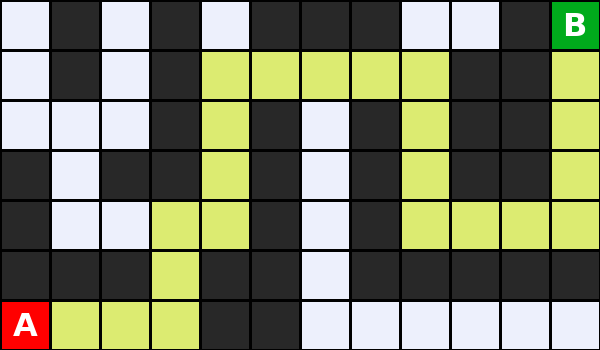


A* with Explored States (orange = explored, yellow = solution):


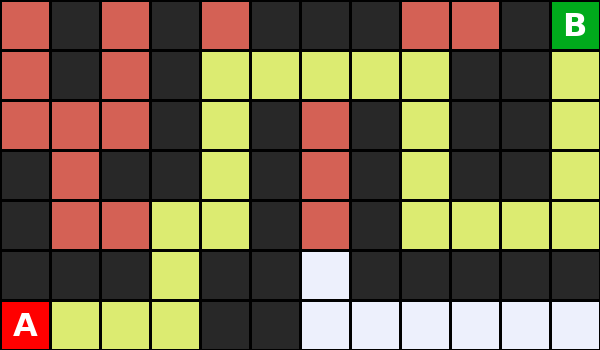

In [70]:
# Step 7e: Generate A* solution image

# Save image showing solution path
m.output_image("maze4_astar.png", show_solution=True, show_explored=False)

# Save image showing both solution and explored states
m.output_image("maze4_astar_explored.png", show_solution=True, show_explored=True)

# Display the images in notebook
from IPython.display import Image as IPImage, display

print("\nA* Solution (yellow = solution path):")
display(IPImage(filename="maze4_astar.png"))

print("\nA* with Explored States (orange = explored, yellow = solution):")
display(IPImage(filename="maze4_astar_explored.png"))

Solving with Greedy Best-First Search...
Solution found!
States explored: 28
Path length: 23 steps

Maze with Greedy solution:

 █ █ ███  █B
 █ █*****██*
   █*█ █*██*
█ ██*█ █*██*
█  **█ █****
███*██ █████
A***██      

Image saved to: maze4_greedy.png
Image saved to: maze4_greedy_explored.png

Greedy Solution:


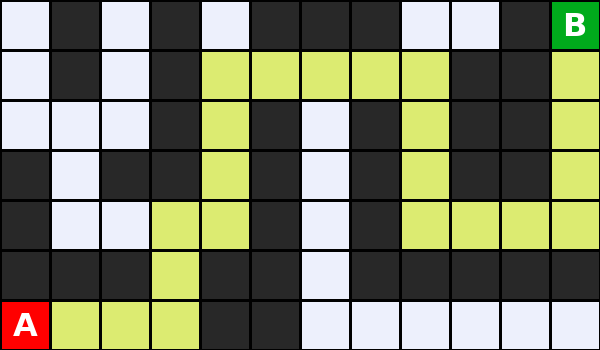


Greedy with Explored States:


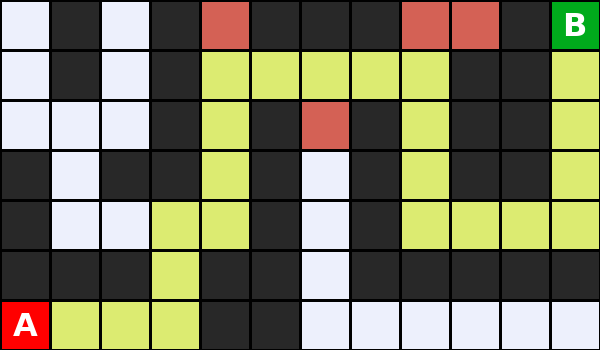

In [71]:
# Step 7f: Test with Greedy Best-First Search

# Create a new maze instance for Greedy
m_greedy = Maze("maze4.txt")

print("Solving with Greedy Best-First Search...")
m_greedy.solve_greedy()

print(f"Solution found!")
print(f"States explored: {m_greedy.num_explored}")
print(f"Path length: {len(m_greedy.solution[0])} steps")

print("\nMaze with Greedy solution:")
m_greedy.print()

# Generate images
m_greedy.output_image("maze4_greedy.png", show_solution=True, show_explored=False)
m_greedy.output_image("maze4_greedy_explored.png", show_solution=True, show_explored=True)

print("\nGreedy Solution:")
display(IPImage(filename="maze4_greedy.png"))

print("\nGreedy with Explored States:")
display(IPImage(filename="maze4_greedy_explored.png"))

In [72]:
# Step 7g: Final Comparison on maze4

print("=" * 60)
print("FINAL COMPARISON: Greedy vs A* on maze4")
print("=" * 60)

print(f"\n{'Algorithm':<25} {'States Explored':>15} {'Path Length':>15}")
print("-" * 60)
print(f"{'Greedy Best-First':<25} {m_greedy.num_explored:>15} {len(m_greedy.solution[0]):>15}")
print(f"{'A* Search':<25} {m.num_explored:>15} {len(m.solution[0]):>15}")
print("-" * 60)

if len(m_greedy.solution[0]) > len(m.solution[0]):
    print(f"\nA* found a SHORTER path! ({len(m.solution[0])} vs {len(m_greedy.solution[0])} steps)")
    print("This demonstrates that Greedy is NOT optimal.")
elif len(m_greedy.solution[0]) == len(m.solution[0]):
    print(f"\nBoth found paths of the same length ({len(m.solution[0])} steps).")
    print("In this case, Greedy happened to find an optimal path.")
else:
    print(f"\nGreedy found a shorter path (unusual with admissible heuristic).")

FINAL COMPARISON: Greedy vs A* on maze4

Algorithm                 States Explored     Path Length
------------------------------------------------------------
Greedy Best-First                      28              23
A* Search                              40              23
------------------------------------------------------------

Both found paths of the same length (23 steps).
In this case, Greedy happened to find an optimal path.


### Step 7 Summary

We created a complete `Maze` class that:

| Method | Description |
|--------|-------------|
| `__init__(filename)` | Load and parse maze from file |
| `print()` | Display maze in terminal (with solution if solved) |
| `neighbors(state)` | Get valid moves from a position |
| `solve_greedy()` | Solve using Greedy Best-First Search |
| `solve_astar()` | Solve using A* Search |
| `output_image(filename)` | Save colorful PNG image |

**Image Color Scheme:**
| Color | Meaning |
|-------|---------|
| Dark Gray | Wall |
| Red + "A" | Start position |
| Green + "B" | Goal position |
| Yellow | Solution path |
| Orange | Explored states |
| Light Gray | Empty cells |

**Usage Example:**
```python
m = Maze("maze4.txt")
m.solve_astar()       # or m.solve_greedy()
m.print()
m.output_image("solution.png", show_explored=True)
```

**Next:** Let's test on a different maze (maze5) to see how the algorithms perform on different problems!

## Step 8: Testing on Multiple Mazes

Let's test our algorithms on a different maze (`maze5.txt`) to see how they perform on different problem structures.

**Why test multiple mazes?**
- Different maze structures can show different algorithm behaviors
- Some mazes may reveal Greedy's weakness (finding non-optimal paths)
- A* should always find the optimal path (with admissible heuristic)

### Maze5 Structure

```
#          B   ← Row 0: Goal B at (0, 11)
# ######### 
# #       # 
# # ##### # 
#   #     # 
### # ##### 
A   #         ← Row 6: Start A at (6, 0)
```

This maze has a different structure - let's see how the algorithms handle it!

In [73]:
# Step 8a: Load and display maze5

m5 = Maze("maze5.txt")

print("Maze5 loaded!")
print(f"Dimensions: {m5.height} x {m5.width}")
print(f"Start: {m5.start}")
print(f"Goal: {m5.goal}")

print("\nMaze5:")
m5.print()

# Show heuristic values for maze5
print("Heuristic values h(n) for maze5:")
for i in range(m5.height):
    for j in range(m5.width):
        if m5.walls[i][j]:
            print("  #", end=" ")
        else:
            h = manhattan_distance((i, j), m5.goal)
            if (i, j) == m5.start:
                print(f"A{h:2d}", end=" ") if h < 10 else print(f"A{h}", end=" ")
            elif (i, j) == m5.goal:
                print("  B", end=" ")
            else:
                print(f" {h:2d}", end=" ")
    print()

Maze5 loaded!
Dimensions: 7 x 12
Start: (6, 0)
Goal: (0, 11)

Maze5:

█          B
█ █████████ 
█ █       █ 
█ █ █████ █ 
█   █     █ 
███ █ █████ 
A   █       

Heuristic values h(n) for maze5:
  #  10   9   8   7   6   5   4   3   2   1   B 
  #  11   #   #   #   #   #   #   #   #   #   1 
  #  12   #  10   9   8   7   6   5   4   #   2 
  #  13   #  11   #   #   #   #   #   5   #   3 
  #  14  13  12   #  10   9   8   7   6   #   4 
  #   #   #  13   #  11   #   #   #   #   #   5 
A17  16  15  14   #  12  11  10   9   8   7   6 


A* SEARCH on maze5

Solution found!
States explored: 32
Path length: 21 steps

Maze5 with A* solution:

█**********B
█*█████████ 
█*█       █ 
█*█ █████ █ 
█***█     █ 
███*█ █████ 
A***█       

Image saved to: maze5_astar.png
Image saved to: maze5_astar_explored.png

A* Solution:


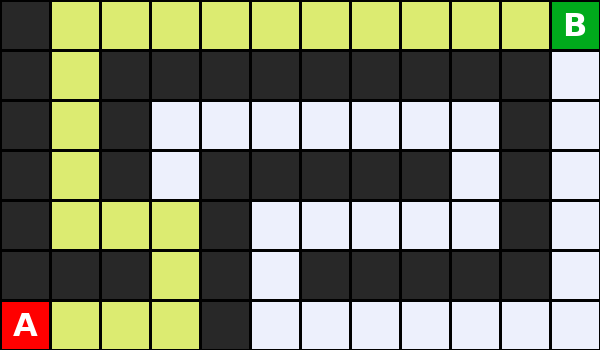

In [74]:
# Step 8b: Solve maze5 with A* Search

m5_astar = Maze("maze5.txt")

print("=" * 50)
print("A* SEARCH on maze5")
print("=" * 50)

m5_astar.solve_astar()

print(f"\nSolution found!")
print(f"States explored: {m5_astar.num_explored}")
print(f"Path length: {len(m5_astar.solution[0])} steps")

print("\nMaze5 with A* solution:")
m5_astar.print()

# Generate images
m5_astar.output_image("maze5_astar.png", show_explored=False)
m5_astar.output_image("maze5_astar_explored.png", show_explored=True)

print("\nA* Solution:")
display(IPImage(filename="maze5_astar.png"))

GREEDY BEST-FIRST SEARCH on maze5

Solution found!
States explored: 34
Path length: 33 steps

Maze5 with Greedy solution:

█          B
█ █████████*
█ █*******█*
█ █*█████*█*
█  *█*****█*
███*█*█████*
A***█*******

Image saved to: maze5_greedy.png
Image saved to: maze5_greedy_explored.png

Greedy Solution:


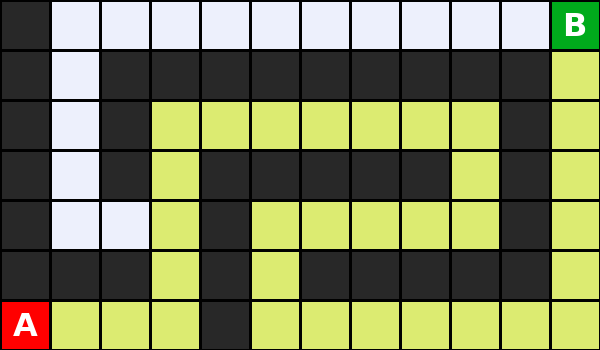

In [75]:
# Step 8c: Solve maze5 with Greedy Best-First Search

m5_greedy = Maze("maze5.txt")

print("=" * 50)
print("GREEDY BEST-FIRST SEARCH on maze5")
print("=" * 50)

m5_greedy.solve_greedy()

print(f"\nSolution found!")
print(f"States explored: {m5_greedy.num_explored}")
print(f"Path length: {len(m5_greedy.solution[0])} steps")

print("\nMaze5 with Greedy solution:")
m5_greedy.print()

# Generate images
m5_greedy.output_image("maze5_greedy.png", show_explored=False)
m5_greedy.output_image("maze5_greedy_explored.png", show_explored=True)

print("\nGreedy Solution:")
display(IPImage(filename="maze5_greedy.png"))

In [76]:
# Step 8d: Compare results on maze5

print("=" * 60)
print("COMPARISON: Greedy vs A* on maze5")
print("=" * 60)

print(f"\n{'Algorithm':<25} {'States Explored':>15} {'Path Length':>15}")
print("-" * 60)
print(f"{'Greedy Best-First':<25} {m5_greedy.num_explored:>15} {len(m5_greedy.solution[0]):>15}")
print(f"{'A* Search':<25} {m5_astar.num_explored:>15} {len(m5_astar.solution[0]):>15}")
print("-" * 60)

diff = len(m5_greedy.solution[0]) - len(m5_astar.solution[0])
if diff > 0:
    print(f"\nA* found a SHORTER path by {diff} steps!")
    print("Greedy was fooled by the heuristic and took a longer route.")
elif diff == 0:
    print(f"\nBoth found the optimal path ({len(m5_astar.solution[0])} steps).")
else:
    print(f"\nUnexpected: Greedy found shorter path (check heuristic).")

COMPARISON: Greedy vs A* on maze5

Algorithm                 States Explored     Path Length
------------------------------------------------------------
Greedy Best-First                      34              33
A* Search                              32              21
------------------------------------------------------------

A* found a SHORTER path by 12 steps!
Greedy was fooled by the heuristic and took a longer route.


In [77]:
# Step 8e: Comprehensive comparison across both mazes

print("=" * 70)
print("COMPREHENSIVE COMPARISON: All Results")
print("=" * 70)

# Results table
results = [
    ("maze4", "Greedy", m_greedy.num_explored, len(m_greedy.solution[0])),
    ("maze4", "A*", m.num_explored, len(m.solution[0])),
    ("maze5", "Greedy", m5_greedy.num_explored, len(m5_greedy.solution[0])),
    ("maze5", "A*", m5_astar.num_explored, len(m5_astar.solution[0])),
]

print(f"\n{'Maze':<10} {'Algorithm':<15} {'Explored':>12} {'Path Length':>12} {'Optimal?':>10}")
print("-" * 70)

for maze, algo, explored, path_len in results:
    # Check if optimal (compare with A* for same maze)
    if algo == "A*":
        optimal = "Yes"
    else:
        # Find A* result for same maze
        astar_len = [r[3] for r in results if r[0] == maze and r[1] == "A*"][0]
        optimal = "Yes" if path_len == astar_len else "No"
    
    print(f"{maze:<10} {algo:<15} {explored:>12} {path_len:>12} {optimal:>10}")

print("-" * 70)

COMPREHENSIVE COMPARISON: All Results

Maze       Algorithm           Explored  Path Length   Optimal?
----------------------------------------------------------------------
maze4      Greedy                    28           23        Yes
maze4      A*                        40           23        Yes
maze5      Greedy                    34           33         No
maze5      A*                        32           21        Yes
----------------------------------------------------------------------


### Step 8 Summary

We tested both algorithms on two different mazes and observed:

**Key Findings:**

| Finding | Explanation |
|---------|-------------|
| A* always finds optimal path | Because it considers g(n) + h(n), balancing actual cost and estimate |
| Greedy may find longer paths | Because it only looks at h(n), ignoring how far it has traveled |
| Greedy often explores fewer states | Because it heads directly toward the goal (but may miss shortcuts) |
| A* explores more strategically | It may backtrack when a path becomes too expensive |

**When to use which algorithm?**

| Use Case | Recommended Algorithm |
|----------|----------------------|
| Need **optimal** (shortest) path | **A\*** |
| Need **any** path quickly | **Greedy** (faster, but not optimal) |
| Memory is limited | **Greedy** (smaller frontier) |
| Path quality matters | **A\*** |

**Remember:** Both algorithms require a good heuristic! The heuristic must be:
- **Admissible** (never overestimate) for A* to be optimal
- **Consistent** (triangle inequality) for efficiency

---

## Tutorial Complete!

### What We Learned

In this tutorial, we covered **Informed Search Algorithms** for maze solving:

#### 1. Key Concepts
- **Heuristic h(n)**: Estimated cost from node n to goal
- **Path cost g(n)**: Actual cost from start to node n
- **Evaluation function f(n)**: Determines which node to expand next

#### 2. Algorithms Implemented

| Algorithm | f(n) | Optimal? | Complete? |
|-----------|------|----------|-----------|
| **Greedy Best-First** | h(n) | No | Yes* |
| **A\*** | g(n) + h(n) | Yes** | Yes |

*With cycle detection  
**With admissible heuristic

#### 3. Data Structures
- **Node**: Stores state, parent, action, g_cost, h_cost, f_cost
- **PriorityQueueFrontier**: Min-heap ordered by f_cost

#### 4. Heuristics
- **Manhattan Distance**: |row1-row2| + |col1-col2|
- Always **admissible** and **consistent** for 4-directional grid movement

#### 5. Comparison with Uninformed Search

| Property | DFS | BFS | Greedy | A* |
|----------|-----|-----|--------|-----|
| Data Structure | Stack | Queue | Priority Queue | Priority Queue |
| Optimal | No | Yes* | No | Yes** |
| Uses Heuristic | No | No | Yes | Yes |
| f(n) | - | - | h(n) | g(n)+h(n) |

*For unweighted graphs  
**With admissible heuristic

### Files Generated
- `maze4_astar.png`, `maze4_astar_explored.png`
- `maze4_greedy.png`, `maze4_greedy_explored.png`
- `maze5_astar.png`, `maze5_astar_explored.png`
- `maze5_greedy.png`, `maze5_greedy_explored.png`

### Next Steps
- Try implementing other heuristics (Euclidean distance)
- Test on larger, more complex mazes
- Compare with uninformed search (DFS/BFS) on the same mazes
- Explore weighted graphs where step costs vary